# 05b — CORAL Adaptation (3-Class Pipeline)
### NeuroReach | Mohina Rustamova
**Goal:** Apply CORAL domain adaptation using the 3-class ViT trained on OASIS.
- Source: OASIS (CN, MCI, AD)
- Target: ADNI v2 (122 subjects, unlabeled)
- Save CORAL-adapted weights to Google Drive

In [1]:
# ============================================================
# Cell 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import os
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


In [2]:
# ============================================================
# Cell 2 — Setup Kaggle API
# ============================================================
from google.colab import files
print('Upload your kaggle.json:')
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API configured.')

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Kaggle API configured.


In [3]:
# ============================================================
# Cell 3 — Install Dependencies + Imports
# ============================================================
!pip install timm pydicom -q

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset, Subset
from torchvision import transforms, datasets
from torch.optim.lr_scheduler import CosineAnnealingLR
from collections import defaultdict
from pathlib import Path
import pydicom
import timm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.6 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# Cell 4 — Download Datasets
# ============================================================
# Download OASIS (source domain)
!kaggle datasets download -d ninadaithal/imagesoasis -p /content/oasis --unzip
print('OASIS downloaded.')

# Download ADNI v2 (target domain — unlabeled)
!kaggle datasets download -d mohinarustamova/neuroreach-adni-v2 -p /content/adni_v2 --unzip
print('ADNI v2 downloaded.')

# Check ADNI v2 structure
count = 0
for root, dirs, files_list in os.walk('/content/adni_v2'):
    for f in files_list[:1]:
        print(os.path.join(root, f))
        count += 1
    if count >= 5:
        break

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:59<00:00, 22.1MB/s]

OASIS downloaded.
Dataset URL: https://www.kaggle.com/datasets/mohinarustamova/neuroreach-adni-v2
License(s): unknown
100% 1.58G/1.58G [01:15<00:00, 22.3MB/s]

ADNI v2 downloaded.
/content/adni_v2/neuroreach_adni_v2_6_25_2026.csv
/content/adni_v2/neuroreach_adni_v2/ADNI/023_S_0625/MPRAGE/2006-07-12_14_23_13.0/I18906/ADNI_023_S_0625_MR_MPRAGE_br_raw_20060713183937687_108_S16766_I18906.dcm
/content/adni_v2/neuroreach_adni_v2/ADNI/051_S_1131/MPRAGE/2007-01-18_11_49_06.0/I36802/ADNI_051_S_1131_MR_MPRAGE_br_raw_20070119141416827_116_S25285_I36802.dcm
/content/adni_v2/neuroreach_adni_v2/ADNI/133_S_0912/MPRAGE/2006-10-23_13_35_34.0/I27400/ADNI_133_S_0912_MR_MPRAGE_br_raw_20061025103700844_26_S20947_I27400.dcm
/content/adni_v2/neuroreach_adni_v2/ADNI/033_S_0920/MPRAGE/2006-10-23_14_43_02.0/I27336/ADNI_033_S_0920_MR_MPRAGE_br_raw_20061024154135963_150_S20897_I273

In [5]:
# ============================================================
# Cell 5 — Build OASIS 3-Class Source DataLoader
# ============================================================
DATA_DIR   = '/content/oasis/Data'
IMG_SIZE   = 224
BATCH_SIZE = 32

LABEL_MAP = {0: 2, 2: 0, 3: 1}  # Drop Moderate Dementia (1)
CLASS_NAMES_3 = ['CN', 'MCI', 'AD']

source_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class ThreeClassDataset(Dataset):
    def __init__(self, dataset, label_map, transform=None):
        self.transform = transform
        self.samples = []
        for path, label in dataset.samples:
            if label in label_map:
                self.samples.append((path, label_map[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        from PIL import Image
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

full_dataset  = datasets.ImageFolder(root=DATA_DIR)
source_dataset = ThreeClassDataset(full_dataset, LABEL_MAP, transform=source_transforms)

# Use 70% for CORAL source training
train_size = int(0.70 * len(source_dataset))
rest_size  = len(source_dataset) - train_size
train_subset, _ = torch.utils.data.random_split(
    source_dataset, [train_size, rest_size],
    generator=torch.Generator().manual_seed(42)
)

# Weighted sampler
train_labels   = [source_dataset.samples[i][1] for i in train_subset.indices]
class_counts   = np.bincount(train_labels)
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

source_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler)
print(f'Source (OASIS) batches: {len(source_loader)}')

Source (OASIS) batches: 1881


In [6]:
# ============================================================
# Cell 6 — Build ADNI v2 Target DataLoader (Unlabeled)
# ============================================================
# Update ADNI_ROOT after checking Cell 4 output
ADNI_ROOT = '/content/adni_v2/neuroreach_adni_v2/ADNI'

adni_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Collect DICOM files
adni_files  = []
subject_ids = []
for dcm_path in Path(ADNI_ROOT).rglob('*.dcm'):
    subject_id = dcm_path.parts[-5]
    adni_files.append(str(dcm_path))
    subject_ids.append(subject_id)

# Group by subject
subject_to_files = defaultdict(list)
for path, subj in zip(adni_files, subject_ids):
    subject_to_files[subj].append(path)
for subj in subject_to_files:
    subject_to_files[subj].sort()

print(f'Total DICOM files : {len(adni_files)}')
print(f'Unique subjects   : {len(subject_to_files)}')

class ADNIUnlabeledDataset(Dataset):
    def __init__(self, subject_to_files, slices_per_subject=10, transform=None):
        self.transform = transform
        self.samples   = []
        for subj, files in subject_to_files.items():
            n      = len(files)
            start  = int(0.20 * n)
            end    = int(0.80 * n)
            usable = files[start:end]
            indices = np.linspace(0, len(usable) - 1, slices_per_subject, dtype=int)
            for i in indices:
                self.samples.append(usable[i])
        print(f'Total target samples: {len(self.samples)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        dcm = pydicom.dcmread(self.samples[idx])
        img = dcm.pixel_array.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.stack([img, img, img], axis=0)
        img = torch.tensor(img, dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img

adni_dataset = ADNIUnlabeledDataset(subject_to_files, slices_per_subject=10, transform=adni_transforms)
adni_loader  = DataLoader(adni_dataset, batch_size=32, shuffle=True, num_workers=2)
print(f'Target (ADNI v2) batches: {len(adni_loader)}')

Total DICOM files : 22960
Unique subjects   : 122
Total target samples: 1220
Target (ADNI v2) batches: 39


In [7]:
# ============================================================
# Cell 7 — Load 3-Class ViT + Define Feature Extractor
# ============================================================
VIT_PATH = '/content/drive/MyDrive/NeuroReach/vit_3class_oasis.pth'

vit_model = timm.create_model('vit_base_patch16_224', pretrained=False)
vit_model.head = nn.Linear(vit_model.head.in_features, 3)
vit_model.load_state_dict(torch.load(VIT_PATH, map_location=device))
vit_model = vit_model.to(device)
print('3-class ViT loaded successfully.')

class ViTFeatureExtractor(nn.Module):
    def __init__(self, vit):
        super().__init__()
        self.vit = vit

    def forward(self, x):
        return self.vit.forward_features(x)[:, 0, :]  # CLS token [B, 768]

feature_extractor = ViTFeatureExtractor(vit_model).to(device)
classifier        = vit_model.head  # Linear(768, 3)

# Freeze classifier
for param in classifier.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

# Sanity check
dummy = torch.randn(4, 3, 224, 224).to(device)
feats = feature_extractor(dummy)
print(f'Feature shape: {feats.shape}')  # expect [4, 768]

3-class ViT loaded successfully.
Trainable parameters: 85,798,656
Feature shape: torch.Size([4, 768])


In [8]:
# ============================================================
# Cell 8 — CORAL Loss Function
# ============================================================
def coral_loss(source_features, target_features):
    d  = source_features.size(1)  # 768
    ns = source_features.size(0)
    nt = target_features.size(0)

    source = source_features - source_features.mean(dim=0, keepdim=True)
    target = target_features - target_features.mean(dim=0, keepdim=True)

    cov_source = (source.T @ source) / (ns - 1)
    cov_target = (target.T @ target) / (nt - 1)

    loss = torch.norm(cov_source - cov_target, p='fro') ** 2
    loss = loss / (4 * d * d)
    return loss

# Sanity check
dummy_src = torch.randn(32, 768).to(device)
dummy_tgt = torch.randn(32, 768).to(device)
test_loss = coral_loss(dummy_src, dummy_tgt)
print(f'CORAL loss (random): {test_loss.item():.4f}')
print(f'Is scalar: {test_loss.shape == torch.Size([])}')

CORAL loss (random): 0.0161
Is scalar: True


In [10]:
# ============================================================
# Cell 9 — CORAL Training Loop (200 batches per epoch)
# ============================================================
EPOCHS = 5
LR     = 1e-5
LAMBDA = 1.0

optimizer  = optim.Adam(feature_extractor.parameters(), lr=LR)
scheduler  = CosineAnnealingLR(optimizer, T_max=EPOCHS)
ce_loss_fn = nn.CrossEntropyLoss()

target_iter = iter(adni_loader)
history = {'total_loss': [], 'ce_loss': [], 'coral_loss': []}

for epoch in range(EPOCHS):
    feature_extractor.train()
    total_sum, ce_sum, coral_sum = 0, 0, 0

    for batch_idx, (source_imgs, source_labels) in enumerate(source_loader):
        if batch_idx >= 200:  # limit to 200 batches per epoch
            break

        source_imgs   = source_imgs.to(device)
        source_labels = source_labels.to(device)

        try:
            target_imgs = next(target_iter)
        except StopIteration:
            target_iter = iter(adni_loader)
            target_imgs = next(target_iter)
        target_imgs = target_imgs.to(device)

        source_feats = feature_extractor(source_imgs)
        target_feats = feature_extractor(target_imgs)
        source_preds = classifier(source_feats)

        ce    = ce_loss_fn(source_preds, source_labels)
        coral = coral_loss(source_feats, target_feats)
        loss  = ce + LAMBDA * coral

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        ce_sum    += ce.item()
        coral_sum += coral.item()

    scheduler.step()

    avg_total = total_sum / 200
    avg_ce    = ce_sum    / 200
    avg_coral = coral_sum / 200

    history['total_loss'].append(avg_total)
    history['ce_loss'].append(avg_ce)
    history['coral_loss'].append(avg_coral)

    print(f'Epoch [{epoch+1}/{EPOCHS}] '
          f'Total: {avg_total:.4f} | '
          f'CE: {avg_ce:.4f} | '
          f'CORAL: {avg_coral:.4f}')

Epoch [1/5] Total: 0.0675 | CE: 0.0491 | CORAL: 0.0184
Epoch [2/5] Total: 0.0506 | CE: 0.0360 | CORAL: 0.0145
Epoch [3/5] Total: 0.0256 | CE: 0.0146 | CORAL: 0.0110
Epoch [4/5] Total: 0.0136 | CE: 0.0059 | CORAL: 0.0078
Epoch [5/5] Total: 0.0115 | CE: 0.0047 | CORAL: 0.0068


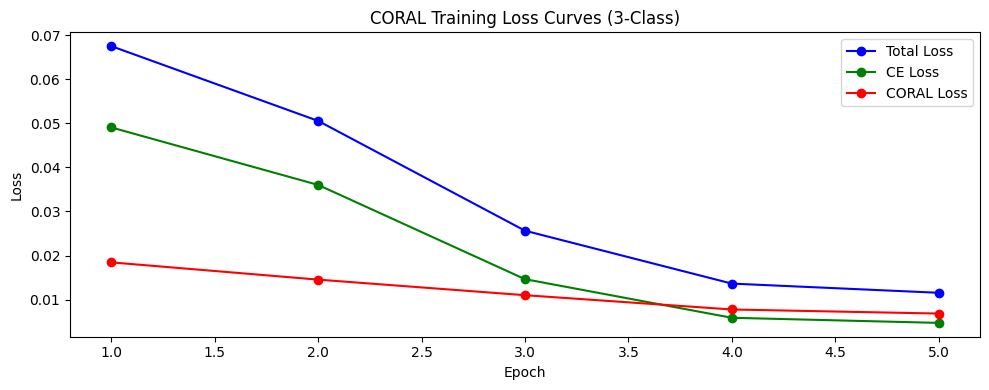

Loss curves saved.


In [11]:
# ============================================================
# Cell 10 — Plot Loss Curves
# ============================================================
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history['total_loss'], 'b-o', label='Total Loss')
plt.plot(epochs_range, history['ce_loss'],    'g-o', label='CE Loss')
plt.plot(epochs_range, history['coral_loss'], 'r-o', label='CORAL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CORAL Training Loss Curves (3-Class)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NeuroReach/coral_3class_loss_curves.png', dpi=150)
plt.show()
print('Loss curves saved.')

In [12]:
# ============================================================
# Cell 11 — Save CORAL-Adapted Weights to Google Drive
# ============================================================
SAVE_PATH = '/content/drive/MyDrive/NeuroReach/vit_3class_coral_adapted.pth'
torch.save(feature_extractor.state_dict(), SAVE_PATH)
print(f'CORAL-adapted 3-class ViT saved to: {SAVE_PATH}')

print(f'\nCORAL Training Summary:')
for i, (total, ce, coral) in enumerate(zip(
    history['total_loss'], history['ce_loss'], history['coral_loss'])):
    print(f'  Epoch {i+1}: Total={total:.4f} | CE={ce:.4f} | CORAL={coral:.4f}')

CORAL-adapted 3-class ViT saved to: /content/drive/MyDrive/NeuroReach/vit_3class_coral_adapted.pth

CORAL Training Summary:
  Epoch 1: Total=0.0675 | CE=0.0491 | CORAL=0.0184
  Epoch 2: Total=0.0506 | CE=0.0360 | CORAL=0.0145
  Epoch 3: Total=0.0256 | CE=0.0146 | CORAL=0.0110
  Epoch 4: Total=0.0136 | CE=0.0059 | CORAL=0.0078
  Epoch 5: Total=0.0115 | CE=0.0047 | CORAL=0.0068
